# Finite Difference Method for Quantum Mechanics

Essential functions for solving quantum mechanical problems using finite difference methods.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg
from scipy.sparse.linalg import eigsh

In [22]:
def spatial(x_left, x_right, N):
    return np.linspace(x_left, x_right, N+2)[1:-1]

def proj(f, grid):
    return np.array([f(point) for point in grid], dtype=complex)

In [ ]:
def _diag(A, C, grid):
    x = grid
    del_x = x[1] - x[0]
    N = len(x)
    
    rows = np.arange(N)
    cols = rows
    
    a = proj(A, x)
    c = proj(C, x)
    data = c - (2.0 * a) / (del_x**2)
    
    return rows, cols, data

def _upper(A, B, grid):
    x = grid[:-1]  # all except last point
    del_x = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(N-1)
    cols = rows + 1
    
    a = proj(A, x)
    b = proj(B, x)
    data = (a / (del_x**2)) + (b / (2.0 * del_x))
    
    return rows, cols, data

def _lower(A, B, grid):
    x = grid[1:]  # all except first point
    del_x = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(1, N)
    cols = rows - 1
    
    a = proj(A, x)
    b = proj(B, x)
    data = (a / (del_x**2)) - (b / (2.0 * del_x))
    
    return rows, cols, data

In [ ]:
def sparseMatrixMaker(A, B, C, grid):
    rD, cD, dD = _diag(A, C, grid)
    rU, cU, dU = _upper(A, B, grid)
    rL, cL, dL = _lower(A, B, grid)

    rows = np.concatenate([rD, rU, rL])
    cols = np.concatenate([cD, cU, cL])
    data = np.concatenate([dD, dU, dL])

    N = len(grid)
    return sparse.coo_matrix((data, (rows, cols)), shape=(N, N))

In [25]:
def _fd_weights_second_derivative(offsets):
    offs = np.asarray(offsets, dtype=complex)
    m = len(offs)
    A = np.zeros((m, m), dtype=complex)
    b = np.zeros(m, dtype=complex)
    b[2] = 2.0
    for k in range(m):
        A[k, :] = offs**k
    return np.linalg.solve(A, b)

# 4th-order stencil offsets
_OFF_CENT = np.array([-2,-1, 0, 1, 2], dtype=int)
_OFF_L0   = np.array([ 0, 1, 2, 3, 4], dtype=int)   
_OFF_L1   = np.array([-1, 0, 1, 2, 3], dtype=int)
_OFF_R1   = np.array([-3,-2,-1, 0, 1], dtype=int)   
_OFF_R0   = np.array([-4,-3,-2,-1, 0], dtype=int)   

_W_CENT = _fd_weights_second_derivative(_OFF_CENT)
_W_L0   = _fd_weights_second_derivative(_OFF_L0)
_W_L1   = _fd_weights_second_derivative(_OFF_L1)
_W_R1   = _fd_weights_second_derivative(_OFF_R1)
_W_R0   = _fd_weights_second_derivative(_OFF_R0)

In [ ]:
def _triplets_4th_Au_xx_plus_Cu(A, C, grid):
    x = np.asarray(grid, dtype=complex)
    h = x[1] - x[0]
    N = x.size

    a = np.array([A(xi) for xi in x], dtype=complex)
    c = np.array([C(xi) for xi in x], dtype=complex)

    rows, cols, data = [], [], []

    def add_row(i, offsets, W):
        for off, w in zip(offsets, W/(h*h)):
            j = i + off
            if 0 <= j < N:
                rows.append(i); cols.append(j); data.append(a[i]*w)
        rows.append(i); cols.append(i); data.append(c[i])
        
    # handle boundaries and interior differently
    add_row(0, _OFF_L0, _W_L0)
    add_row(1, _OFF_L1, _W_L1)
    
    for i in range(2, N-2):
        add_row(i, _OFF_CENT, _W_CENT)
    
    add_row(N-2, _OFF_R1, _W_R1)
    add_row(N-1, _OFF_R0, _W_R0)

    return np.array(rows), np.array(cols), np.array(data)

def sparse_Matrix_Maker4(A, C, grid):
    r, c, d = _triplets_4th_Au_xx_plus_Cu(A, C, grid)
    N = len(grid)
    return sparse.coo_matrix((d, (r, c)), shape=(N, N))

In [27]:
def hamiltonian(V, x_left, x_right, N):
    N = int(N)
    grid = spatial(x_left, x_right, N)
    
    def A(x): return -0.5  # kinetic energy coefficient
    def B(x): return 0.0
    def C(x): return V(x)  # potential energy
    
    return sparseMatrixMaker(A, B, C, grid).tocsr()

def hamiltonian_4th(V, x_left, x_right, N):
    N = int(N)
    grid = spatial(x_left, x_right, N)
    
    def A(x): return -0.5
    def C(x): return V(x)
    
    return sparse_Matrix_Maker4(A, C, grid).tocsr()

## Timing Comparison: 2nd vs 4th Order Methods


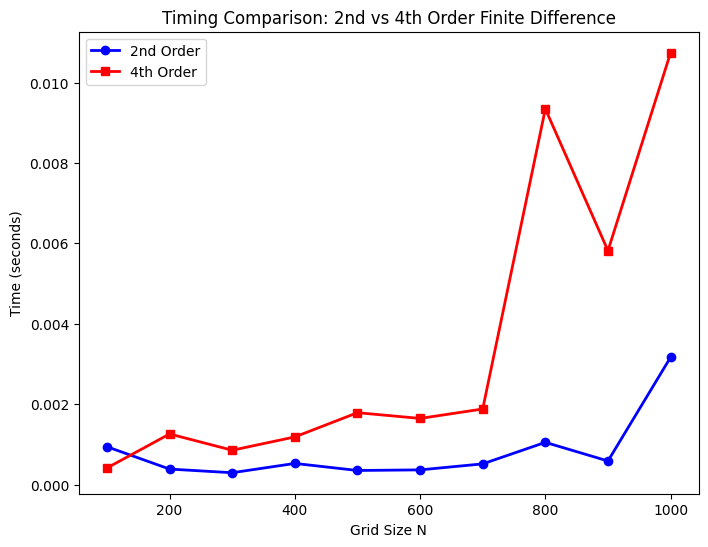

In [28]:
import time

def timing_hamiltonian_2nd(N):
    def V(x): return 0.5 * x**2
    x_left, x_right = -5.0, 5.0
    start = time.time()
    H = hamiltonian(V, x_left, x_right, N)
    end = time.time()
    return end - start

def timing_hamiltonian_4th(N):
    def V(x): return 0.5 * x**2
    x_left, x_right = -5.0, 5.0
    start = time.time()
    H = hamiltonian_4th(V, x_left, x_right, N)
    end = time.time()
    return end - start

N_values = np.arange(100, 1001, 100)
timing_2nd = []
timing_4th = []

for N in N_values:
    timing_2nd.append(timing_hamiltonian_2nd(N))
    timing_4th.append(timing_hamiltonian_4th(N))

plt.figure(figsize=(8, 6))
plt.plot(N_values, timing_2nd, 'b-o', label='2nd Order', linewidth=2, markersize=6)
plt.plot(N_values, timing_4th, 'r-s', label='4th Order', linewidth=2, markersize=6)
plt.xlabel('Grid Size N')
plt.ylabel('Time (seconds)')
plt.title('Timing Comparison: 2nd vs 4th Order Finite Difference')
plt.legend()
plt.show()



## Convergence Analysis: 4th Order Method


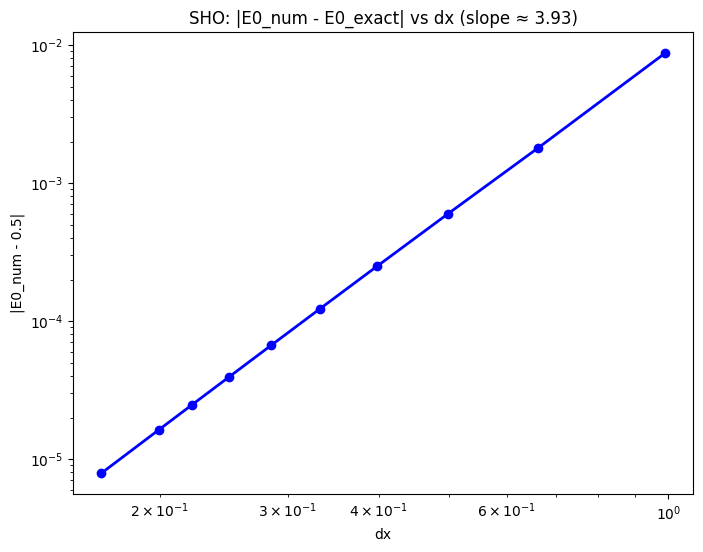

In [29]:
def E_exact_sho(n, omega=1.0): 
    return n + 0.5

target_n = 0
E0_exact = E_exact_sho(target_n)

x_inf = 100.0 
x_left, x_right = -x_inf, x_inf

def V(x): 
    return 0.5 * x**2

N_list = [201, 301, 401, 501, 601, 701, 801, 901, 1001, 1201]
errs, dxs = [], []

for N_test in N_list:
    Ht = hamiltonian_4th(V, x_left, x_right, N_test)
    Et, _ = eigsh(Ht, k=1, which='SM', tol=1e-10, maxiter=2000)
    Et = np.min(Et)
    grid_t = spatial(x_left, x_right, N_test)
    dx = grid_t[1] - grid_t[0]
    error = abs(Et - E0_exact)
    
    dxs.append(dx)
    errs.append(error)

plt.figure(figsize=(8, 6))
plt.loglog(dxs, errs, 'bo-', linewidth=2, markersize=6)

slope = (np.log(errs[-1]) - np.log(errs[0])) / (np.log(dxs[-1]) - np.log(dxs[0]))
plt.title(f"SHO: |E0_num - E0_exact| vs dx (slope ≈ {slope:.2f})")
plt.xlabel("dx")
plt.ylabel("|E0_num - 0.5|")
plt.show()
